### Setup

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
from apatools.lm import lm, lm_report, base_metrics, mlm_icc
from apatools.format import format_p, get_stars
import statsmodels.formula.api as smf
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
def lr_test(formula, data, groups): # if p<0.05 then use random effects
    """Likelihood ratio test for random effects (approximate)."""
    mixed = smf.mixedlm(formula, data=data, groups=groups, missing='drop').fit(reml=False)
    ols = smf.ols(formula, data=data).fit()
    lrt = 2 * (mixed.llf - ols.llf)
    # mixture distribution: 0.5 * chi2(0) + 0.5 * chi2(1)
    p = 0.5 * stats.chi2.sf(lrt, 1)
    return lrt, p

get_col = lambda x, r: [c for c in r.columns for i in x if i == c]

In [3]:
base_dir = './'
results_dir = os.path.join(base_dir, "results")
data_dir = os.path.join(base_dir, "data")

In [4]:
df = pd.read_csv(os.path.join(results_dir, "data.csv"), index_col=0)
print(f"N={len(df)}")
s = "mean_shared_capacity"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "mean_degree"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "lifetime"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")

n = (df["mean_shared_capacity"] > 0) &\
    (df["mean_degree"] > 0) &\
    (df["lifetime"] > 0)

print(f"\nRemove nodes with zero capacity, lifetime or degree (n={len(df[~n])}, {len(df[~n])/len(df)*100:.2f}%):")
df = df[n]
print(f"N={len(df)}")
s = "mean_shared_capacity"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "mean_degree"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "lifetime"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")

results = {}
df.head()

N=39159
mean_shared_capacity == 0: n=2586, 6.60%
mean_degree == 0: n=693, 1.77%
lifetime == 0: n=709, 1.81%

Remove nodes with zero capacity, lifetime or degree (n=3678, 9.39%):
N=35481
mean_shared_capacity == 0: n=0, 0.00%
mean_degree == 0: n=0, 0.00%
lifetime == 0: n=0, 0.00%


,lifetime,mean_shared_capacity,mean_degree,region,country,latitude,longitude,log_mean_degree,log_lifetime,log_mean_shared_capacity,gdp_cap,log_gdp_cap
0,42,1.292802e+07,15.750000,Bavaria,DE,49.4542,11.0775,1.224015,1.633468,7.111532,43961.056336,4.643078
1,98,1.000000e+05,2.000000,NaN,NaN,NaN,NaN,0.477121,1.995635,5.000004,NaN,NaN
2,145,2.218966e+05,1.724138,NaN,NaN,NaN,NaN,0.435229,2.164353,5.346153,NaN,NaN
3,509,3.939878e+07,34.150000,Uusimaa,FI,60.1695,24.9354,1.545925,2.707570,7.595483,45550.955048,4.658507
4,1596,3.077402e+06,23.651613,Grand Est,FR,48.5839,7.7455,1.391845,3.203305,6.488184,38126.602922,4.581240


### Distribution analysis

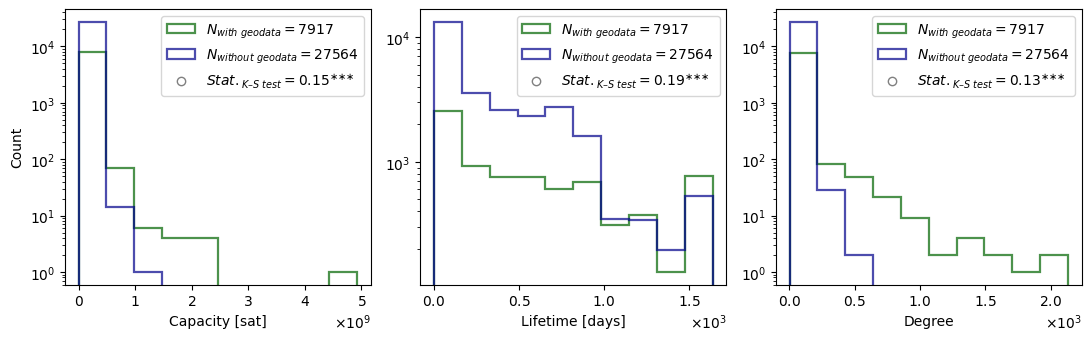

In [14]:
def add_stat(a, b, ax, test='mannwhitney'):
    if test == 'mannwhitney':
        s, p = stats.mannwhitneyu(a, b)
        t = "${Stat.}_{M–W~test} = $"
    else:
        s, p = stats.ks_2samp(a, b)
        t = "${Stat.}_{K–S~test} = $"
    hs, ls = ax.get_legend_handles_labels()
    rl = Line2D(
        [0],
        [0],
        marker="o",
        color="gray",
        markerfacecolor="white",
        markersize=6,
        linewidth=0.0,
    )
    return hs + [rl], ls + [
        t + f"{s:.2f}" + "$^{" + get_stars(p).replace('*', r'{\ast}') + "}$"
    ]

d = df.copy()
lw = 1.6
n_bins = 11
alpha = 0.7
test = 'ks' #'mannwhitney'
g = d["country"].notna()
fig = plt.figure(figsize=(11, 3.5))
ax_left = fig.add_subplot(1, 3, 1)

s = "mean_shared_capacity"
d0 = d[s] # full
d1 = d[g][s] # geodata
d2 = d[~g][s] # no geodata
bins = np.linspace(d0.min(), d0.max(), n_bins)
d1.hist(ax=ax_left, bins=bins, label=f"$N_{{with~geodata}}={len(d1)}$", lw=lw,
            log=True, color='darkgreen', grid=False, alpha=alpha, histtype='step')
d2.hist(ax=ax_left, bins=bins, label=f"$N_{{without~geodata}}={len(d2)}$", lw=lw,
                  log=True, color='darkblue', grid=False, alpha=alpha, histtype='step')
hs, ls = add_stat(d1, d2, ax_left, test)
ax_left.legend(hs, ls, loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_left.xaxis.set_major_formatter(xfmt)
ax_left.set_xlabel("Capacity [sat]")
ax_left.set_ylabel("Count")

ax_center = fig.add_subplot(1, 3, 2)
s = "lifetime"
d0 = d[s] # full
d1 = d[g][s] # geodata
d2 = d[~g][s] # no geodata
bins = np.linspace(d0.min(), d0.max(), n_bins)
d1.hist(ax=ax_center, bins=bins, label=f"$N_{{with~geodata}}={len(d1)}$", lw=lw,
            log=True, color='darkgreen', grid=False, alpha=alpha, histtype='step')
d2.hist(ax=ax_center, bins=bins, label=f"$N_{{without~geodata}}={len(d2)}$", lw=lw,
                  log=True, color='darkblue', grid=False, alpha=alpha, histtype='step')
hs, ls = add_stat(d1, d2, ax_center, test)
ax_center.legend(hs, ls, loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_center.xaxis.set_major_formatter(xfmt)
ax_center.set_xlabel("Lifetime [days]")

ax_right= fig.add_subplot(1, 3, 3)
s = "mean_degree"
d0 = d[s] # full
d1 = d[g][s] # geodata
d2 = d[~g][s] # no geodata
bins = np.linspace(d0.min(), d0.max(), n_bins)
d1.hist(ax=ax_right, bins=bins, label=f"$N_{{with~geodata}}={len(d1)}$", lw=lw,
            log=True, color='darkgreen', grid=False, alpha=alpha, histtype='step')
d2.hist(ax=ax_right, bins=bins, label=f"$N_{{without~geodata}}={len(d2)}$", lw=lw,
                  log=True, color='darkblue', grid=False, alpha=alpha, histtype='step')
hs, ls = add_stat(d1, d2, ax_right, test)
ax_right.legend(hs, ls, loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_right.xaxis.set_major_formatter(xfmt)
ax_right.set_xlabel("Degree")

fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig02.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format='pdf',
    )

### Correlation analysis

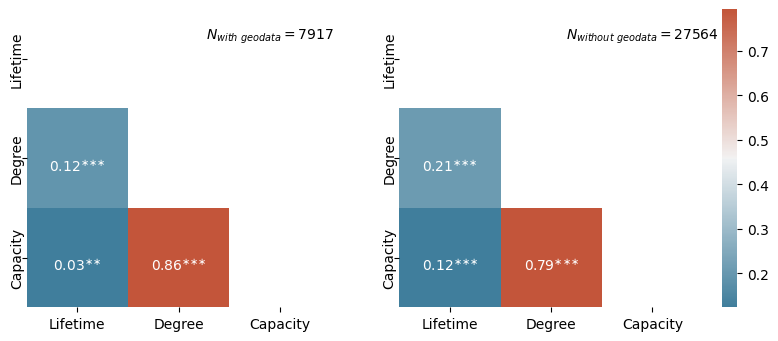

In [15]:
d = df.copy().rename(columns={
    "lifetime": "Lifetime",
    "mean_degree": "Degree",
    "mean_shared_capacity": "Capacity"})
g = d["country"].notna()
d1 = d[["Lifetime", "Degree", "Capacity"]][g] # geodata
d2 = d[["Lifetime", "Degree", "Capacity"]][~g] # no geodata
fig = plt.figure(figsize=(8, 3.5))
ax_left = fig.add_subplot(1, 2, 1)
c = d1.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").statistic)
p = d1.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").pvalue)
a = c.copy().astype(str)
for i in a.keys():
    for j in a[i].keys():
        a.loc[i, j] = f"{c[i][j]:.2f}$^{{{get_stars(p[i][j])}}}$".replace('*', '{\\ast}')
cmap = sns.diverging_palette(230, 20, n=256, as_cmap=True) #cmap="YlGnBu"
mask = np.triu(np.ones_like(c, dtype=bool))
ax_left = sns.heatmap(c, cmap=cmap, mask=mask, annot_kws={'va':'top'}, fmt='', 
                 robust=False, ax=ax_left, cbar=True, annot=a)
ax_left.set_yticklabels(labels=ax_left.get_yticklabels(), ha='center', rotation=90)
ax_left.collections[0].colorbar.ax.set_visible(False)
ax_left.text(2.4, 0.3, f"$N_{{with~geodata}}={len(d1)}$", ha='center')

ax_right = fig.add_subplot(1, 2, 2)  
c = d2.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").statistic)
p = d2.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").pvalue)
a = c.copy().astype(str)
for i in a.keys():
    for j in a[i].keys():
        a.loc[i, j] = f"{c[i][j]:.2f}$^{{{get_stars(p[i][j])}}}$".replace('*', r'{\ast}')
#cmap = sns.diverging_palette(230, 20, n=256, as_cmap=True)
mask = np.triu(np.ones_like(c, dtype=bool))
ax_right = sns.heatmap(c, cmap=cmap, mask=mask, annot_kws={'va':'top'}, fmt='', 
                 robust=False, ax=ax_right, cbar=True, annot=a) 
ax_right.set_yticklabels(labels=ax_right.get_yticklabels(), ha='center', rotation=90)
ax_right.text(2.4, 0.3, f"$N_{{without~geodata}}={len(d2)}$", ha='center')

fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig03.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format='pdf',
    )


## Hypoteses

### H1 Lifetime → Capacity

In [10]:
# H1 Lifetime → Capacity (RLM) nogeo_sample
d = df.copy()
d = d[d["country"].isna()]
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(RLM)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=27564
formula: log_mean_shared_capacity ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D75247AD0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                27564
Model:                                  RLM   Df Residuals:                    27562
Method:                                IRLS   Df Model:                            1
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:05                                         
No. Iterations:                           8                     

'β=0.21***, 95%CI [0.19, 0.23]'

In [11]:
# H1 Lifetime → Capacity (OLS) nogeo_sample
d = df.copy()
d = d[d["country"].isna()]
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(OLS)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=27564
formula: log_mean_shared_capacity ~ 1 + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.014
Model:                                  OLS   Adj. R-squared:                  0.014
Method:                       Least Squares   F-statistic:                     402.2
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):           7.89e-89
Time:                              11:51:05   Log-Likelihood:                -40135.
No. Observations:                     27564   AIC:                         8.027e+04
Df Residuals:                         27562   BIC:                         8.029e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                   coef    std err          t 

'β=0.21***, 95%CI [0.19, 0.23]'

In [12]:
# H1 Lifetime → Capacity (RLM) geo_sample
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(RLM)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D73C84980>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7915
Method:                                IRLS   Df Model:                            1
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:05                                         
No. Iterations:                           6                      

'β=0.05*, 95%CI [0.00, 0.09]'

In [13]:
# H1 Lifetime → Capacity (OLS) geo_sample
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(OLS)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.001
Model:                                  OLS   Adj. R-squared:                  0.000
Method:                       Least Squares   F-statistic:                     4.433
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):             0.0353
Time:                              11:51:05   Log-Likelihood:                -12810.
No. Observations:                      7917   AIC:                         2.562e+04
Df Residuals:                          7915   BIC:                         2.564e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                   coef    std err          t  

'β=0.05*, 95%CI [0.00, 0.09]'

In [14]:
# H1 Lifetime → Capacity (RLM) geo_sample+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(RLM)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D73AE7E60>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7914
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:05                                         
No. Iterations:                           8            

'β=0.05*, 95%CI [0.00, 0.09]'

In [15]:
# H1 Lifetime → Capacity (OLS) geo_sample+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "country"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(OLS)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_lifetime + country
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.001
Model:                                  OLS   Adj. R-squared:                  0.001
Method:                       Least Squares   F-statistic:                     3.376
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):             0.0342
Time:                              11:51:05   Log-Likelihood:                -12809.
No. Observations:                      7917   AIC:                         2.562e+04
Df Residuals:                          7914   BIC:                         2.565e+04
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                   coef    std err   

'β=0.05*, 95%CI [0.00, 0.09]'

In [16]:
# H1 Lifetime → Capacity (RLM) geo_sample+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "country", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(RLM)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_lifetime + country + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D75184500>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7913
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:05                                         
No. Iterations:                          12   

'β=0.08***, 95%CI [0.04, 0.12]'

In [17]:
# H1 Lifetime → Capacity (OLS) geo_sample+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "country", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(OLS)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_lifetime + country + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.040
Model:                                  OLS   Adj. R-squared:                  0.039
Method:                       Least Squares   F-statistic:                     109.0
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):           3.53e-69
Time:                              11:51:06   Log-Likelihood:                -12652.
No. Observations:                      7917   AIC:                         2.531e+04
Df Residuals:                          7913   BIC:                         2.534e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                   coef    s

'β=0.08***, 95%CI [0.04, 0.12]'

In [18]:
# H1 Lifetime → Capacity (RLM) geo_sample+gdp
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(RLM)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D755AB080>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7893
Model:                                  RLM   Df Residuals:                     7890
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:06                                         
No. Iterations:                           7        

'β=0.05*, 95%CI [0.00, 0.09]'

In [19]:
# H1 Lifetime → Capacity (OLS) geo_sample+gdp
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "log_gdp_cap"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(OLS)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893


formula: log_mean_shared_capacity ~ 1 + log_lifetime + log_gdp_cap
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.001
Model:                                  OLS   Adj. R-squared:                  0.000
Method:                       Least Squares   F-statistic:                     2.961
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):             0.0518
Time:                              11:51:06   Log-Likelihood:                -12776.
No. Observations:                      7893   AIC:                         2.556e+04
Df Residuals:                          7890   BIC:                         2.558e+04
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                   coef    std err     

'β=0.04*, 95%CI [0.00, 0.09]'

In [20]:
# H1 Lifetime → Capacity (RLM) geo_sample+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "log_gdp_cap", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(RLM)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + log_lifetime + log_gdp_cap + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D752D4410>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7893
Model:                                  RLM   Df Residuals:                     7889
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:06                                         
No. Iterations:                          1

'β=0.08***, 95%CI [0.04, 0.12]'

In [21]:
# H1 Lifetime → Capacity (OLS) geo_sample+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "log_gdp_cap", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H1(OLS)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + log_lifetime + log_gdp_cap + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.041
Model:                                  OLS   Adj. R-squared:                  0.041
Method:                       Least Squares   F-statistic:                     112.6
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):           2.16e-71
Time:                              11:51:06   Log-Likelihood:                -12614.
No. Observations:                      7893   AIC:                         2.524e+04
Df Residuals:                          7889   BIC:                         2.526e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                   coef 

'β=0.08***, 95%CI [0.03, 0.12]'

In [22]:
# H1 Lifetime → Capacity (MLM) geo+country
f = "log_mean_shared_capacity ~ log_lifetime"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+country'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .07, R²adj = .07, F(1, 7916) = 628.02, p < .0001, AIC = 25105.1, BIC = 25133.0, LL = -12548.5, MAE = 0.951, MAD = 0.933, N = 7917, G = 97,
 ICC = 0.07, LRTstat. = 81723.2 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              1.3789                  
Min. group size:  1       Log-Likelihood:     -12548.5433             
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
-------------------------------------------------------------------------
                 Coef.    Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        5.718       0.073    78.743    0.00

'β=0.10***, 95%CI [0.06, 0.14]'

In [23]:
# H1 Lifetime → Capacity (MLM) geo_sample+country+region
f = "log_mean_shared_capacity ~ log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+country+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .11, R²adj = .11, F(1, 7916) = 958.25, p < .0001, AIC = 24471.1, BIC = 24506.0, LL = -12230.5, MAE = 0.874, MAD = 0.788, N = 7917, G = 97,
 ICC = 0.00, LRTstat. = 81723.2 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              1.2468                  
Min. group size:  1       Log-Likelihood:     -12230.5374             
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
-------------------------------------------------------------------------
                 Coef.    Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        5.617       0.059   

'β=0.14***, 95%CI [0.10, 0.18]'

In [24]:
# H1 Lifetime → Capacity (MLM) geo_sample+gdp
f = "log_mean_shared_capacity ~ log_lifetime + log_gdp_cap"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+gdp'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .07, R²adj = .07, F(2, 7891) = 305.13, p < .0001, AIC = 25036.7, BIC = 25071.6, LL = -12513.4, MAE = 0.952, MAD = 0.932, N = 7893, G = 90,
 ICC = 0.07, LRTstat. = 525.4 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + log_gdp_cap + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7893    Method:             ML                      
No. Groups:       90      Scale:              1.3805                  
Min. group size:  1       Log-Likelihood:     -12513.3590             
Max. group size:  2600    Converged:          Yes                     
Mean group size:  87.7                                                
-------------------------------------------------------------------------
                  Coef.    Std.Err.      z      P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept         4.722       0.513    9

'β=0.10***, 95%CI [0.06, 0.14]'

In [25]:
# H1 Lifetime → Capacity (MLM) geo_sample+gdp+region
f = "log_mean_shared_capacity ~ log_lifetime + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+gdp+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .15, R²adj = .15, F(2, 7891) = 678.57, p < .0001, AIC = 24410.6, BIC = 24452.4, LL = -12199.3, MAE = 0.874, MAD = 0.787, N = 7893, G = 90,
 ICC = 0.07, LRTstat. = 525.4 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + log_gdp_cap + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7893    Method:             ML                      
No. Groups:       90      Scale:              1.2462                  
Min. group size:  1       Log-Likelihood:     -12199.2839             
Max. group size:  2600    Converged:          No                      
Mean group size:  87.7                                                
-------------------------------------------------------------------------
                  Coef.    Std.Err.      z      P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept         4.582  

'β=0.14***, 95%CI [0.10, 0.18]'

### H2-1 Lifetime → Degree

In [26]:
# H2-1 Lifetime → Degree (RLM) nogeo_sample
d = df.copy()
d = d[d["country"].isna()]
m, i = lm(d, "log_mean_degree", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(RLM)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=27564
formula: log_mean_degree ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D73FE5FD0>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                27564
Model:                            RLM   Df Residuals:                    27562
Method:                          IRLS   Df Model:                            1
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 24 Mar 2026                                         
Time:                        11:51:28                                         
No. Iterations:                    19                                         
                   coef    std err          z   

'β=0.13***, 95%CI [0.12, 0.13]'

In [27]:
# H2-1 Lifetime → Degree (OLS) nogeo_sample
d = df.copy()
d = d[d["country"].isna()]
m, i = lm(d, "log_mean_degree", ["log_lifetime"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(OLS)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=27564
formula: log_mean_degree ~ 1 + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                            OLS Regression Results                            
Dep. Variable:        log_mean_degree   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1198.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.42e-257
Time:                        11:51:28   Log-Likelihood:                -11885.
No. Observations:               27564   AIC:                         2.377e+04
Df Residuals:                   27562   BIC:                         2.379e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

'β=0.13***, 95%CI [0.12, 0.14]'

In [28]:
# H2-1 Lifetime → Degree (RLM) geo_sample
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_degree", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(RLM)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_degree ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D755AA990>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 7917
Model:                            RLM   Df Residuals:                     7915
Method:                          IRLS   Df Model:                            1
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 24 Mar 2026                                         
Time:                        11:51:29                                         
No. Iterations:                    13                                         
                   coef    std err          z    

'β=0.09***, 95%CI [0.07, 0.11]'

In [29]:
# H2-1 Lifetime → Degree (OLS) geo_sample
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_degree", ["log_lifetime"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(OLS)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_degree ~ 1 + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                            OLS Regression Results                            
Dep. Variable:        log_mean_degree   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     110.7
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.00e-25
Time:                        11:51:29   Log-Likelihood:                -6199.1
No. Observations:                7917   AIC:                         1.240e+04
Df Residuals:                    7915   BIC:                         1.242e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

'β=0.10***, 95%CI [0.08, 0.12]'

In [30]:
# H2-1 Lifetime → Degree (RLM) geo_sample+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_degree", ["log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(RLM)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_degree ~ 1 + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D755AA570>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 7917
Model:                            RLM   Df Residuals:                     7914
Method:                          IRLS   Df Model:                            2
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 24 Mar 2026                                         
Time:                        11:51:29                                         
No. Iterations:                    13                                         
                   coef    std err     

'β=0.09***, 95%CI [0.07, 0.11]'

In [31]:
# H2-1 Lifetime → Degree (OLS) geo_sample+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_degree", ["log_lifetime", "country"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(OLS)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_degree ~ 1 + log_lifetime + country
model: OLS
model_kwargs: {}
fit_kwargs: {}
                            OLS Regression Results                            
Dep. Variable:        log_mean_degree   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     55.46
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.20e-24
Time:                        11:51:29   Log-Likelihood:                -6199.0
No. Observations:                7917   AIC:                         1.240e+04
Df Residuals:                    7914   BIC:                         1.242e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

'β=0.10***, 95%CI [0.08, 0.12]'

In [32]:
# H2-1 Lifetime → Degree (RLM) geo_sample+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_degree", ["log_lifetime", "country", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(RLM)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_degree ~ 1 + log_lifetime + country + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D755AA510>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 7917
Model:                            RLM   Df Residuals:                     7913
Method:                          IRLS   Df Model:                            3
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 24 Mar 2026                                         
Time:                        11:51:29                                         
No. Iterations:                    19                                         
                   coef    std

'β=0.10***, 95%CI [0.08, 0.12]'

In [33]:
# H2-1 Lifetime → Degree (OLS) geo_sample+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_degree", ["log_lifetime", "country", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(OLS)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_degree ~ 1 + log_lifetime + country + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                            OLS Regression Results                            
Dep. Variable:        log_mean_degree   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     130.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.07e-82
Time:                        11:51:29   Log-Likelihood:                -6062.5
No. Observations:                7917   AIC:                         1.213e+04
Df Residuals:                    7913   BIC:                         1.216e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------

'β=0.11***, 95%CI [0.09, 0.13]'

In [34]:
# H2-1 Lifetime → Degree (RLM) geo_sample+gdp
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_degree", ["log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(RLM)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_degree ~ 1 + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D3EFB2450>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 7893
Model:                            RLM   Df Residuals:                     7890
Method:                          IRLS   Df Model:                            2
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 24 Mar 2026                                         
Time:                        11:51:29                                         
No. Iterations:                    17                                         
                   coef    std err 

'β=0.09***, 95%CI [0.07, 0.11]'

In [35]:
# H2-1 Lifetime → Degree (OLS) geo_sample+gdp
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_degree", ["log_lifetime", "log_gdp_cap"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(OLS)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893


formula: log_mean_degree ~ 1 + log_lifetime + log_gdp_cap
model: OLS
model_kwargs: {}
fit_kwargs: {}
                            OLS Regression Results                            
Dep. Variable:        log_mean_degree   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     54.89
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           2.12e-24
Time:                        11:51:29   Log-Likelihood:                -6184.6
No. Observations:                7893   AIC:                         1.238e+04
Df Residuals:                    7890   BIC:                         1.240e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

'β=0.10***, 95%CI [0.08, 0.12]'

In [36]:
# H2-1 Lifetime → Degree (RLM) geo_sample+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_degree", ["log_lifetime", "log_gdp_cap", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(RLM)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_degree ~ 1 + log_lifetime + log_gdp_cap + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D7560A6F0>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 7893
Model:                            RLM   Df Residuals:                     7889
Method:                          IRLS   Df Model:                            3
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Tue, 24 Mar 2026                                         
Time:                        11:51:29                                         
No. Iterations:                    19                                         
                   coef   

'β=0.10***, 95%CI [0.08, 0.12]'

In [37]:
# H2-1 Lifetime → Degree (OLS) geo_sample+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_degree", ["log_lifetime", "log_gdp_cap", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H21(OLS)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_degree ~ 1 + log_lifetime + log_gdp_cap + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                            OLS Regression Results                            
Dep. Variable:        log_mean_degree   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     131.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           2.52e-83
Time:                        11:51:29   Log-Likelihood:                -6046.1
No. Observations:                7893   AIC:                         1.210e+04
Df Residuals:                    7889   BIC:                         1.213e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------

'β=0.11***, 95%CI [0.09, 0.13]'

In [38]:
# H2-1 Lifetime → Degree (MLM) geo_sample+country
f = "log_mean_degree ~ log_lifetime"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+country'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .07, R²adj = .07, F(1, 7916) = 611.93, p < .0001, AIC = 11991.0, BIC = 12018.9, LL = -5991.5, MAE = 0.403, MAD = 0.492, N = 7917, G = 97,
 ICC = 0.05, LRTstat. = 26600.8 (p < .0001)
log_mean_degree ~ log_lifetime + (1 | country)  
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 7917    Method:             ML             
No. Groups:       97      Scale:              0.2635         
Min. group size:  1       Log-Likelihood:     -5991.4820     
Max. group size:  2600    Converged:          Yes            
Mean group size:  81.6                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.723     0.030  23.989  0.000   0.664   0.782
log_lifetime    0.119     0.009  12.790  0.000   0.100   0.137
Group Var       0.015     0

'β=0.12***, 95%CI [0.10, 0.14]'

In [39]:
# H2-1 Lifetime → Degree (MLM) geo_sample+country+region
f = "log_mean_degree ~ log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+country+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .10, R²adj = .10, F(1, 7916) = 878.09, p < .0001, AIC = 11475.2, BIC = 11510.1, LL = -5732.6, MAE = 0.375, MAD = 0.420, N = 7917, G = 97,
 ICC = 0.00, LRTstat. = 26600.8 (p < .0001)
log_mean_degree ~ log_lifetime + (1 | country)  +  (1 | region)
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 7917    Method:             ML             
No. Groups:       97      Scale:              0.2429         
Min. group size:  1       Log-Likelihood:     -5732.6036     
Max. group size:  2600    Converged:          Yes            
Mean group size:  81.6                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.682     0.024  28.347  0.000   0.635   0.729
log_lifetime    0.133     0.009  14.792  0.000   0.116   0.151
Group Var   

'β=0.13***, 95%CI [0.12, 0.15]'

In [40]:
# H2-1 Lifetime → Degree (MLM) geo_sample+gdp
f = "log_mean_degree ~ log_lifetime + log_gdp_cap"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+gdp'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


R² = .07, R²adj = .07, F(2, 7891) = 304.10, p < .0001, AIC = 11963.6, BIC = 11998.5, LL = -5976.8, MAE = 0.403, MAD = 0.493, N = 7893, G = 90,
 ICC = 0.05, LRTstat. = 415.6 (p < .0001)
log_mean_degree ~ log_lifetime + log_gdp_cap + (1 | country)  
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 7893    Method:             ML             
No. Groups:       90      Scale:              0.2638         
Min. group size:  1       Log-Likelihood:     -5976.8002     
Max. group size:  2600    Converged:          Yes            
Mean group size:  87.7                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.488     0.209   2.330  0.020   0.077   0.898
log_lifetime    0.118     0.009  12.723  0.000   0.100   0.136
log_gdp_cap    

'β=0.12***, 95%CI [0.10, 0.14]'

In [41]:
# H2-1 Lifetime → Degree (MLM) geo_sample+gdp+region
f = "log_mean_degree ~ log_lifetime + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+gdp+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .10, R²adj = .10, F(2, 7891) = 442.97, p < .0001, AIC = 11448.5, BIC = 11490.3, LL = -5718.2, MAE = 0.375, MAD = 0.420, N = 7893, G = 90,
 ICC = 0.00, LRTstat. = 415.6 (p < .0001)
log_mean_degree ~ log_lifetime + log_gdp_cap + (1 | country)  +  (1 | region)
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 7893    Method:             ML             
No. Groups:       90      Scale:              0.2430         
Min. group size:  1       Log-Likelihood:     -5718.2258     
Max. group size:  2600    Converged:          Yes            
Mean group size:  87.7                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.545                                         
log_lifetime    0.133     0.009  14.813  0.000   0.115   0.150


'β=0.13***, 95%CI [0.12, 0.15]'

### H2-2 Degree → Capacity (controlling for Lifetime)

In [42]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) nogeo_sample
d = df.copy()
d = d[d["country"].isna()]
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime",], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(RLM)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=27564
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D3EFB3200>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                27564
Model:                                  RLM   Df Residuals:                    27561
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:41                                         
No. Iterations:                           9   

'β=2.27***, 95%CI [2.25, 2.29]'

In [43]:
# H2-2 Degree → Capacity (controlling for Lifetime) (OLS) nogeo_sample
d = df.copy()
d = d[d["country"].isna()]
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime",], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(OLS)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=27564
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.660
Model:                                  OLS   Adj. R-squared:                  0.660
Method:                       Least Squares   F-statistic:                 2.671e+04
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              11:51:41   Log-Likelihood:                -25481.
No. Observations:                     27564   AIC:                         5.097e+04
Df Residuals:                         27561   BIC:                         5.099e+04
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                      coef  

'β=2.25***, 95%CI [2.23, 2.27]'

In [44]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime",], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(RLM)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D75339820>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7914
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:41                                         
No. Iterations:                          11    

'β=2.00***, 95%CI [1.97, 2.02]'

In [45]:
# H2-2 Degree → Capacity (controlling for Lifetime) (OLS) geo_sample
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime",], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(OLS)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=7917
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.738
Model:                                  OLS   Adj. R-squared:                  0.738
Method:                       Least Squares   F-statistic:                 1.113e+04
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              11:51:41   Log-Likelihood:                -7515.1
No. Observations:                      7917   AIC:                         1.504e+04
Df Residuals:                          7914   BIC:                         1.506e+04
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                      coef   

'β=1.98***, 95%CI [1.95, 2.01]'

In [46]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(RLM)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D752D4D10>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7913
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:41                                         
No. Iterations:                      

'β=2.00***, 95%CI [1.97, 2.02]'

In [47]:
# H2-2 Degree → Capacity (controlling for Lifetime) (OLS) geo_sample+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "country"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(OLS)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=7917
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + country
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.738
Model:                                  OLS   Adj. R-squared:                  0.738
Method:                       Least Squares   F-statistic:                     7424.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              11:51:41   Log-Likelihood:                -7512.6
No. Observations:                      7917   AIC:                         1.503e+04
Df Residuals:                          7913   BIC:                         1.506e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                   

'β=1.98***, 95%CI [1.95, 2.00]'

In [48]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "country", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(RLM)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + country + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D755AAC30>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7912
Method:                                IRLS   Df Model:                            4
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:42                                         
No. Iterations:             

'β=1.97***, 95%CI [1.95, 2.00]'

In [49]:
# H2-2 Degree → Capacity (controlling for Lifetime) (OLS) geo_sample+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "country", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(OLS)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + country + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.739
Model:                                  OLS   Adj. R-squared:                  0.739
Method:                       Least Squares   F-statistic:                     5613.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              11:51:42   Log-Likelihood:                -7488.7
No. Observations:                      7917   AIC:                         1.499e+04
Df Residuals:                          7912   BIC:                         1.502e+04
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
          

'β=1.96***, 95%CI [1.94, 1.99]'

In [50]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample+gdp
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(RLM)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D75378FE0>}
fit_kwargs: {}


                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7893
Model:                                  RLM   Df Residuals:                     7889
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:42                                         
No. Iterations:                          11                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

'β=2.00***, 95%CI [1.97, 2.02]'

In [51]:
# H2-2 Degree → Capacity (controlling for Lifetime) (OLS) geo_sample+gdp
d = df.copy()
d = d.dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "log_gdp_cap"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(OLS)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + log_gdp_cap
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.738
Model:                                  OLS   Adj. R-squared:                  0.738
Method:                       Least Squares   F-statistic:                     7411.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              11:51:42   Log-Likelihood:                -7491.7
No. Observations:                      7893   AIC:                         1.499e+04
Df Residuals:                          7889   BIC:                         1.502e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
               

'β=1.98***, 95%CI [1.95, 2.01]'

In [52]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "log_gdp_cap", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(RLM)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + log_gdp_cap + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000024D752CAFC0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7893
Model:                                  RLM   Df Residuals:                     7888
Method:                                IRLS   Df Model:                            4
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              11:51:42                                         
No. Iterations:         

'β=1.97***, 95%CI [1.95, 2.00]'

In [53]:
# H2-2 Degree → Capacity (controlling for Lifetime) (OLS) geo_sample+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "log_gdp_cap", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H22(OLS)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + log_gdp_cap + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.740
Model:                                  OLS   Adj. R-squared:                  0.740
Method:                       Least Squares   F-statistic:                     5608.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              11:51:42   Log-Likelihood:                -7465.0
No. Observations:                      7893   AIC:                         1.494e+04
Df Residuals:                          7888   BIC:                         1.497e+04
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
      

'β=1.96***, 95%CI [1.94, 1.99]'

In [54]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+country
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+country'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(2, 7915) = 11360.92, p < .0001, AIC = 14850.1, BIC = 14884.9, LL = -7420.0, MAE = 0.473, MAD = 0.379, N = 7917, G = 97,
 ICC = 0.04, LRTstat. = 51508.4 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              0.3784                  
Min. group size:  1       Log-Likelihood:     -7420.0277              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
------------------------------------------------------------------------
                   Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept           4.319      0.037

'β=1.95***, 95%CI [1.93, 1.98]'

In [55]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+country+region
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+country+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(2, 7915) = 11363.27, p < .0001, AIC = 14717.5, BIC = 14759.4, LL = -7352.8, MAE = 0.456, MAD = 0.361, N = 7917, G = 97,
 ICC = 0.02, LRTstat. = 51508.4 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7917    Method:             ML                      
No. Groups:       97      Scale:              0.3671                  
Min. group size:  1       Log-Likelihood:     -7352.7703              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  81.6                                                
------------------------------------------------------------------------
                   Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept           4

'β=1.92***, 95%CI [1.89, 1.94]'

In [56]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+gdp
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+gdp'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(3, 7890) = 7546.09, p < .0001, AIC = 14811.0, BIC = 14852.8, LL = -7399.5, MAE = 0.474, MAD = 0.380, N = 7893, G = 90,
 ICC = 0.04, LRTstat. = 184.4 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7893    Method:             ML                      
No. Groups:       90      Scale:              0.3787                  
Min. group size:  1       Log-Likelihood:     -7399.5005              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  87.7                                                
------------------------------------------------------------------------
                   Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept           3.799

'β=1.95***, 95%CI [1.93, 1.98]'

In [57]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+gdp+region
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+gdp+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(3, 7890) = 7544.93, p < .0001, AIC = 14678.2, BIC = 14727.0, LL = -7332.1, MAE = 0.457, MAD = 0.362, N = 7893, G = 90,
 ICC = 0.01, LRTstat. = 184.4 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 7893    Method:             ML                      
No. Groups:       90      Scale:              0.3675                  
Min. group size:  1       Log-Likelihood:     -7332.1027              
Max. group size:  2600    Converged:          Yes                     
Mean group size:  87.7                                                
------------------------------------------------------------------------
                   Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept 

'β=1.91***, 95%CI [1.89, 1.94]'

### H3 Lifetime × Degree → Capacity

In [7]:
# H3 Lifetime × Degree → Capacity (RLM) nogeo
d = df.copy()
d = d[d["country"].isna()]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(RLM)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=27564
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002196EE767B0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                27564
Model:                                  RLM   Df Residuals:                    27560
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              15:28:23                                         
No. Iterations:             

'β=-0.05**, 95%CI [-0.08, -0.01]'

In [8]:
# H3 Lifetime × Degree → Capacity (OLS) nogeo
d = df.copy()
d = d[d["country"].isna()]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(OLS)+nogeo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=27564
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.660
Model:                                  OLS   Adj. R-squared:                  0.660
Method:                       Least Squares   F-statistic:                 1.781e+04
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              15:28:24   Log-Likelihood:                -25479.
No. Observations:                     27564   AIC:                         5.097e+04
Df Residuals:                         27560   BIC:                         5.100e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
          

'β=-0.04*, 95%CI [-0.07, -0.00]'

In [9]:
# H3 Lifetime × Degree → Capacity (RLM) geo
d = df.copy()
d = d.dropna(subset='country')
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(RLM)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x0000021939BC6C00>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7913
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              15:28:24                                         
No. Iterations:              

'β=0.04*, 95%CI [0.00, 0.09]'

In [10]:
# H3 Lifetime × Degree → Capacity (OLS) geo
d = df.copy()
d = d.dropna(subset='country')
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(OLS)+geo'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.738
Model:                                  OLS   Adj. R-squared:                  0.738
Method:                       Least Squares   F-statistic:                     7433.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              15:28:24   Log-Likelihood:                -7509.3
No. Observations:                      7917   AIC:                         1.503e+04
Df Residuals:                          7913   BIC:                         1.505e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
           

'β=0.08**, 95%CI [0.03, 0.12]'

In [11]:
# H3 Lifetime × Degree → Capacity (RLM) geo+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(RLM)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002196EACE030>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7912
Method:                                IRLS   Df Model:                            4
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              15:28:24                                         
No. Iterations:    

'β=0.04*, 95%CI [0.00, 0.09]'

In [12]:
# H3 Lifetime × Degree → Capacity (OLS) geo+country
d = df.copy()
d = d.dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "country"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(OLS)+geo+country'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=7917
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + country
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.738
Model:                                  OLS   Adj. R-squared:                  0.738
Method:                       Least Squares   F-statistic:                     5579.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              15:28:24   Log-Likelihood:                -7506.8
No. Observations:                      7917   AIC:                         1.502e+04
Df Residuals:                          7912   BIC:                         1.506e+04
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
 

'β=0.08**, 95%CI [0.03, 0.12]'

In [13]:
# H3 Lifetime × Degree → Capacity (RLM) geo+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "country", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(RLM)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + country + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002197022C140>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7917
Model:                                  RLM   Df Residuals:                     7911
Method:                                IRLS   Df Model:                            5
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              15:28:24                                         
No. Iterat

'β=0.04⁺, 95%CI [-0.00, 0.08]'

In [14]:
# H3 Lifetime × Degree → Capacity (OLS) geo+country+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "country", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(OLS)+geo+country+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7917
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + country + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.740
Model:                                  OLS   Adj. R-squared:                  0.740
Method:                       Least Squares   F-statistic:                     4498.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              15:28:24   Log-Likelihood:                -7483.3
No. Observations:                      7917   AIC:                         1.498e+04
Df Residuals:                          7911   BIC:                         1.502e+04
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                  

'β=0.07**, 95%CI [0.03, 0.12]'

In [15]:
# H3 Lifetime × Degree → Capacity (RLM) geo+gdp
d = df.copy()
d = d.dropna(subset='country')
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(RLM)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002196ECB2240>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7893
Model:                                  RLM   Df Residuals:                     7888
Method:                                IRLS   Df Model:                            4
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              15:28:25                                         
No. Iterations:

'β=0.04*, 95%CI [0.00, 0.09]'

In [16]:
# H3 Lifetime × Degree → Capacity (OLS) geo+gdp
d = df.copy()
d = d.dropna(subset='country')
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "log_gdp_cap"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(OLS)+geo+gdp'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=7893
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + log_gdp_cap
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.738
Model:                                  OLS   Adj. R-squared:                  0.738
Method:                       Least Squares   F-statistic:                     5568.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              15:28:25   Log-Likelihood:                -7486.1
No. Observations:                      7893   AIC:                         1.498e+04
Df Residuals:                          7888   BIC:                         1.502e+04
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                       

'β=0.07**, 95%CI [0.03, 0.12]'

In [17]:
# H3 Lifetime × Degree → Capacity (RLM) geo+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "log_gdp_cap", "region"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(RLM)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + log_gdp_cap + region
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002196EDC3890>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 7893
Model:                                  RLM   Df Residuals:                     7887
Method:                                IRLS   Df Model:                            5
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Tue, 24 Mar 2026                                         
Time:                              15:28:25                                         
No. It

'β=0.04⁺, 95%CI [-0.00, 0.08]'

In [18]:
# H3 Lifetime × Degree → Capacity (OLS) geo+gdp+region
d = df.copy()
d = d.dropna(subset='region')
d["country"] = d["country"].astype("category").cat.codes
d["region"] = d["region"].astype("category").cat.codes
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "log_gdp_cap", "region"], model = 'ols',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
results['H3(OLS)+geo+gdp+region'] = r
b = r.iloc[1]
r = r.iloc[0]
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=7893
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + log_gdp_cap + region
model: OLS
model_kwargs: {}
fit_kwargs: {}
                               OLS Regression Results                               
Dep. Variable:     log_mean_shared_capacity   R-squared:                       0.740
Model:                                  OLS   Adj. R-squared:                  0.740
Method:                       Least Squares   F-statistic:                     4494.
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                              15:28:25   Log-Likelihood:                -7459.8
No. Observations:                      7893   AIC:                         1.493e+04
Df Residuals:                          7887   BIC:                         1.497e+04
Df Model:                                 5                                         
Covariance Type:                  nonrobust                              

'β=0.07**, 95%CI [0.03, 0.11]'

In [19]:
# H3 Lifetime × Degree → Capacity (MLM) geo+country
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+country'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(3, 7914) = 7584.52, p < .0001, AIC = 14844.7, BIC = 14886.6, LL = -7416.4, MAE = 0.473, MAD = 0.381, N = 7917, G = 97,
 ICC = 0.04, LRTstat. = 51495.5 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + (1 | country)  
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  7917    Method:             ML                      
No. Groups:        97      Scale:              0.3780                  
Min. group size:   1       Log-Likelihood:     -7416.3688              
Max. group size:   2600    Converged:          Yes                     
Mean group size:   81.6                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     4.4

'β=0.06**, 95%CI [0.02, 0.10]'

In [20]:
# H3 Lifetime × Degree → Capacity (MLM) geo+country+region
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+country+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(3, 7914) = 7587.55, p < .0001, AIC = 14712.9, BIC = 14761.7, LL = -7349.5, MAE = 0.457, MAD = 0.362, N = 7917, G = 97,
 ICC = 0.02, LRTstat. = 51495.5 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + (1 | country)  +  (1 | region)
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  7917    Method:             ML                      
No. Groups:        97      Scale:              0.3668                  
Min. group size:   1       Log-Likelihood:     -7349.4536              
Max. group size:   2600    Converged:          Yes                     
Mean group size:   81.6                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept         

'β=0.06*, 95%CI [0.01, 0.10]'

In [21]:
# H3 Lifetime × Degree → Capacity (MLM) geo+gdp
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap"
vc = {}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+gdp'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(4, 7889) = 5666.95, p < .0001, AIC = 14806.0, BIC = 14854.8, LL = -7396.0, MAE = 0.474, MAD = 0.382, N = 7893, G = 90,
 ICC = 0.04, LRTstat. = 180.2 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap + (1 | country)  
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  7893    Method:             ML                      
No. Groups:        90      Scale:              0.3784                  
Min. group size:   1       Log-Likelihood:     -7396.0044              
Max. group size:   2600    Converged:          Yes                     
Mean group size:   87.7                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept            

'β=0.06**, 95%CI [0.01, 0.10]'

In [22]:
# H3 Lifetime × Degree → Capacity (MLM) geo+gdp+region
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = base_metrics(m)
r = lm_report([m], [i])[0]
r.loc[r.index[0], 'model'] += f',\n ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+gdp+region'] = r
print(r.iloc[0]['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = r.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .74, R²adj = .74, F(4, 7889) = 5667.32, p < .0001, AIC = 14673.9, BIC = 14729.7, LL = -7329.0, MAE = 0.457, MAD = 0.364, N = 7893, G = 90,
 ICC = 0.01, LRTstat. = 180.2 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap + (1 | country)  +  (1 | region)
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  7893    Method:             ML                      
No. Groups:        90      Scale:              0.3672                  
Min. group size:   1       Log-Likelihood:     -7328.9543              
Max. group size:   2600    Converged:          Yes                     
Mean group size:   87.7                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Interc

'β=0.06*, 95%CI [0.01, 0.10]'

### Tables & Figures

In [21]:
var_labels = {
    "country": "Country",
    "region": "Region",
    "region Var": "Region Var.",
    "Group Var": "Country Var.",
    "log_lifetime": "Lifetime",
    "log_mean_degree": "Degree",
    "lifetimeXdegree": "Lifetime × Degree",
    "log_lifetime:log_mean_degree": "Lifetime × Degree",    
    "log_gdp_cap": "GDP per capita",
}
[k for k in results.keys() if 'H1' in k]

[]

In [22]:
# H1 table 01
t = pd.DataFrame()
for h in ['H1']:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['nogeo', '+geo', 'geo+country', 'geo+country+region'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab01.xlsx"))

IndexError: single positional indexer is out-of-bounds

In [ ]:
# H2-1 table 02-1
t = pd.DataFrame()
for h in ['H21']:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['nogeo', '+geo', 'geo+country', 'country+region'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab02-1.xlsx"))

In [ ]:
# H2-2 table 02-2
t = pd.DataFrame()
for h in ['H22']:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['nogeo', '+geo', 'geo+country', 'country+region'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab02-2.xlsx"))

In [ ]:
# H3 table 03
t = pd.DataFrame()
for h in ['H3']:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['nogeo', '+geo', 'geo+country', 'country+region'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab03.xlsx"))

#### GDP

In [ ]:
# GDP table 04-1
t = pd.DataFrame()
for h in ['H1',]:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['geo+gdp+region', 'geo+gdp'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab04-1.xlsx"))

In [ ]:
# GDP table 04-2
t = pd.DataFrame()
for h in ['H21',]:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['geo+gdp+region', 'geo+gdp'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab04-2.xlsx"))

In [ ]:
# GDP table 04-3
t = pd.DataFrame()
for h in ['H22',]:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['geo+gdp+region', 'geo+gdp'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab04-3.xlsx"))

In [ ]:
# GDP table 04-4
t = pd.DataFrame()
for h in ['H3']:
    for m in ['OLS', 'RLM', 'MLM']:
            for k in [k for k in [k for k in results.keys() if h in k and m in k] 
                    for s in ['geo+gdp+region', 'geo+gdp'] 
                        if k.endswith(s)]:
                r = results[k].copy()
                r['coef'] = r.apply(lambda x: x['coef'] if not pd.notna(x['cil']) else
                                    f"{x['coef']:.3f}{x['sig']}\n[{x['cil']:.3f}, {x['cir']:.3f}]", axis=1)
                r['coef'] = r.apply(lambda x: x['coef'] if pd.notna(x['cil']) or pd.isna(x['se']) else
                                    f"{x['coef']:.3f}\n({x['se']:.3f})", axis=1)                
                r.drop(get_col(["se", "t", "z", "p-value", "sig", "cil", "cir"], r), axis=1, inplace=True)
                r.index = r.index.str.replace('const', 'Intercept')
                r.index = pd.Series(r.index).apply(lambda x: var_labels.get(x, x))
                t = pd.concat([t, r.rename(columns={
                    "coef": k})], axis=1)   
m = t.iloc[0][1::2].copy().rename("Model")
t = t.drop("model", axis=1)
m.index = t.columns
t = pd.concat([t, pd.DataFrame(m).T]).fillna("")
t.to_excel(os.path.join(results_dir, "tab04-4.xlsx"))

### Quantille Regression

In [5]:
q_results = {}
quantile_list = np.linspace(0.1, 0.9, 15)

In [6]:
# H3 Lifetime × Degree → Capacity (QLM) nogeo
d = df.copy()
d = d[d["country"].isna()]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
outputs = []
for q in quantile_list:
    m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'qlm',
                                    verbose = False,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    qlm_fit_q=q,
                                    qlm_fit_cov_type='boot',
                                    qlm_fit_cov_kwds={'n_boot': 1000},
                                    rlm_model_M = sm.robust.norms.Hampel())
    r = lm_report(m, i)[0]
    outputs.append(r)
q_results['H3(QLM)+nogeo'] = outputs

In [23]:
# H3 Lifetime × Degree → Capacity (QLM) geo
d = df.copy()
d = d[d["country"].notna()]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
outputs = []
for q in quantile_list:
    m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'qlm',
                                    verbose = False,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    qlm_fit_q=q,
                                    qlm_fit_cov_type='boot',
                                    qlm_fit_cov_kwds={'n_boot': 1000},
                                    rlm_model_M = sm.robust.norms.Hampel())
    r = lm_report(m, i)[0]
    outputs.append(r)
q_results['H3(QLM)+geo'] = outputs

In [24]:
# H3 Lifetime × Degree → Capacity (QLM) full
d = df.copy()
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
outputs = []
for q in quantile_list:
    m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'qlm',
                                    verbose = False,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    qlm_fit_q=q,
                                    qlm_fit_cov_type='boot',
                                    qlm_fit_cov_kwds={'n_boot': 1000},
                                    rlm_model_M = sm.robust.norms.Hampel())
    r = lm_report(m, i)[0]
    outputs.append(r)
q_results['H3(QLM)+full'] = outputs

In [25]:
# H3 Lifetime × Degree → Capacity (RLM) full
d = df.copy()
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'rlm',
                                    verbose = False,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    qlm_fit_q=q,
                                    qlm_fit_cov_type='boot',
                                    qlm_fit_cov_kwds={'n_boot': 1000},
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
q_results['H3(RLM)+full'] = r

In [26]:
# H3 Lifetime × Degree → Capacity (OLS) full
d = df.copy()
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'ols',
                                    verbose = False,
                                    constant = True,
                                    standardized = False,
                                    base_metrics = True,
                                    pred_metrics = False,
                                    qlm_fit_q=q,
                                    qlm_fit_cov_type='boot',
                                    qlm_fit_cov_kwds={'n_boot': 1000},
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
q_results['H3(OLS)+full'] = r

In [27]:
q_results['H3(OLS)+full']['coef']['lifetimeXdegree']

np.float64(-0.0583)

with geodata coef.: -0.070 - 0.104
without geodata coef.: -0.254 - 0.054
full sample coef.: -0.303 - -0.008


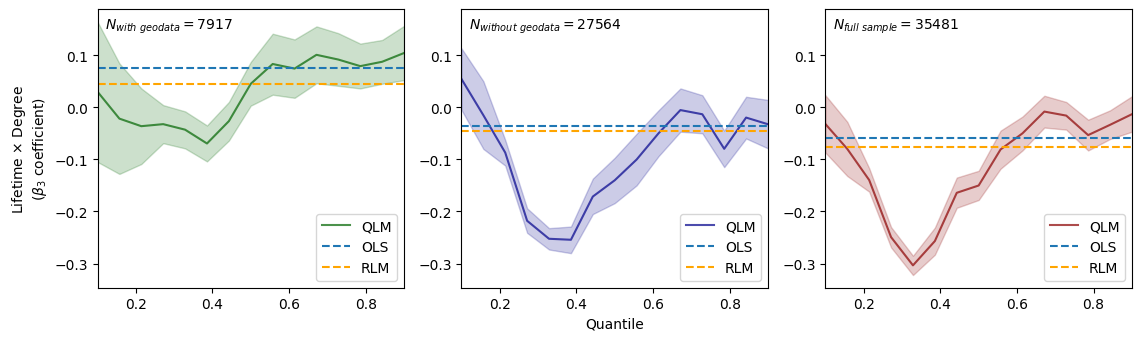

In [33]:
fig = plt.figure(figsize=(11.5, 3.5))
ax_left = fig.add_subplot(1, 3, 1)
coefs = [i['coef']['lifetimeXdegree'] for i in q_results['H3(QLM)+geo']]
lower = [i['cil']['lifetimeXdegree'] for i in q_results['H3(QLM)+geo']]
upper = [i['cir']['lifetimeXdegree'] for i in q_results['H3(QLM)+geo']]
print(f"with geodata coef.: {np.min(coefs):.3f} - {np.max(coefs):.3f}")
ax_left.plot(quantile_list, coefs, color='darkgreen', alpha=0.7, label='QLM')
ax_left.fill_between(quantile_list, lower, upper, alpha=0.2, color='darkgreen')
ax_left.axhline(results['H3(OLS)+geo']['coef']['lifetimeXdegree'], linestyle='--', label='OLS')
ax_left.axhline(results['H3(RLM)+geo']['coef']['lifetimeXdegree'], linestyle='--', label='RLM', color='orange')
ax_left.legend(loc='lower right')
ax_left.set_xlim([0.1, 0.9])
ax_left.set_ylabel('Lifetime $\\times$ Degree\n($\\beta_3$ coefficient)')
ax_left.text(0.12, 0.15, f"$N_{{with~geodata}}={df["country"].notna().sum()}$")

ax_center = fig.add_subplot(1, 3, 2, sharey=ax_left)
coefs = [i['coef']['lifetimeXdegree'] for i in q_results['H3(QLM)+nogeo']]
lower = [i['cil']['lifetimeXdegree'] for i in q_results['H3(QLM)+nogeo']]
upper = [i['cir']['lifetimeXdegree'] for i in q_results['H3(QLM)+nogeo']]
print(f"without geodata coef.: {np.min(coefs):.3f} - {np.max(coefs):.3f}")
ax_center.plot(quantile_list, coefs, color='darkblue', alpha=0.7, label='QLM')
ax_center.fill_between(quantile_list, lower, upper, alpha=0.2, color='darkblue')
ax_center.axhline(results['H3(OLS)+nogeo']['coef']['lifetimeXdegree'], linestyle='--', label='OLS')
ax_center.axhline(results['H3(RLM)+nogeo']['coef']['lifetimeXdegree'], linestyle='--', label='RLM', color='orange')
ax_center.legend(loc='lower right')
ax_center.set_xlim([0.1, 0.9])
ax_center.set_xlabel("Quantile")
ax_center.text(0.12, 0.15, f"$N_{{without~geodata}}={df["country"].isna().sum()}$")

ax_right = fig.add_subplot(1, 3, 3, sharey=ax_left)
coefs = [i['coef']['lifetimeXdegree'] for i in q_results['H3(QLM)+full']]
lower = [i['cil']['lifetimeXdegree'] for i in q_results['H3(QLM)+full']]
upper = [i['cir']['lifetimeXdegree'] for i in q_results['H3(QLM)+full']]
print(f"full sample coef.: {np.min(coefs):.3f} - {np.max(coefs):.3f}")
ax_right.plot(quantile_list, coefs, color='darkred', alpha=0.7, label='QLM')
ax_right.fill_between(quantile_list, lower, upper, alpha=0.2, color='darkred')
ax_right.axhline(q_results['H3(OLS)+full']['coef']['lifetimeXdegree'], linestyle='--', label='OLS')
ax_right.axhline(q_results['H3(RLM)+full']['coef']['lifetimeXdegree'], linestyle='--', label='RLM', color='orange')
ax_right.legend(loc='lower right')
ax_right.set_xlim([0.1, 0.9])
ax_right.text(0.12, 0.15, f"$N_{{full~sample}}={len(df)}$")

fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig04.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format='pdf',
    )
